# Value Iteration

## Learning Objectives

By the end of this notebook, you will be able to:
- explain how value iteration updates state values directly
- implement the Bellman optimality update in a small MDP
- extract a greedy policy from the final value table
- understand why value iteration is different from policy iteration

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 3, lesson 04 "Markov Decision Processes (MDPs) and Value Iteration" — you ran the Bellman update there; this lesson slows it down to show why the max-over-actions form converges without ever storing a policy, and how the greedy policy is read off at the end. Run `02_mdp_solving.ipynb` first.



## Lesson Brief

This lesson focuses on **value iteration**, one of the clearest ways to compute an optimal policy in a small MDP.

Students will learn how repeated Bellman updates gradually improve value estimates until the best action becomes clear in each state.

Why this matters: value iteration gives students a concrete bridge between theory and computation.

It also prepares them to understand why later RL methods approximate values instead of calculating them exactly.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can jump back to re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.

## 🌍 Real case: the collision-avoidance logic in commercial aircraft was built this way

Every large commercial aircraft carries a system that tells the pilot "climb" or "descend" when
another aircraft gets too close. The replacement for the 1980s rule-based TCAS is the **ACAS X**
family, and it was not hand-written. It was *solved*.

Julian, Lopez, Brush, Owen and Kochenderfer open their 2016 paper (*Policy Compression for Aircraft
Collision Avoidance Systems*, DASC 2016) with the sentence that describes this notebook: "One
approach to designing the decision making logic for an aircraft collision avoidance system is to
frame the problem as Markov decision process and optimize the system using dynamic programming. The
resulting strategy can be represented as a numeric table." The states are the encounter geometry —
relative position, relative speed, time to closest approach, which advisory was already given. The
actions are the advisories. The reward trades collision risk against the nuisance of alerting a
pilot who did not need it. Dynamic programming fills in a value for every discretised state, exactly
as the sweeps below will, and the greedy action read off that table *is* the certified logic.
The paper notes that ACAS Xa, the manned-aircraft version, "is expected to become the next
international standard for large commercial transport and cargo aircraft".

**What goes wrong without this.** The alternative is what aviation had before: a large set of
hand-written `if` rules, each individually sensible, tuned by argument. Nobody could prove what the
combination did in an encounter geometry no one had thought of. Value iteration replaces the
argument with a computation — one number per state, and a guarantee that the number is consistent
with every number it depends on. That is what the `delta` you are about to watch shrink actually
measures: how far the table still is from being self-consistent.


## Recommended YouTube Video

To reinforce this lesson, watch **Computerphile - "Solve Markov Decision Processes with the Value Iteration Algorithm"**:
[Watch on YouTube](https://www.youtube.com/watch?v=dZ0SQrr4g8g)

Why this pick:
- Helps students see how repeated Bellman updates lead to a usable policy.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Value: the long-term usefulness of a state.
- Bellman optimality update: update a state using the best available action return.
- Greedy action: the action with the highest current estimated return.
- Sweep: one full pass that updates every non-terminal state once using the Bellman optimality backup. In this notebook the pass is **synchronous**: while computing the sweep, every state reads from the value table frozen at the *start* of that sweep, then all new values are written at the end. That is why distant rewards usually need **many sweeps** to propagate through the grid—each sweep typically carries the signal about one step farther.
- Convergence: when repeated sweeps change the values only a tiny amount.
- Discount factor `gamma`: how strongly future rewards influence the update.

### Quick Check
- Why do values improve through repeated sweeps instead of one pass only?
- Why do we take a `max` over actions in value iteration?
- What does `gamma` change in the update target?
- What sign shows the algorithm is stabilizing?

### Common Mistakes
- Thinking one update is enough.
- Choosing by immediate reward only.
- Confusing updated values with the final policy.
- Thinking `gamma` is just a technical constant instead of a long-term preference setting.


## Big idea

In policy iteration, you alternate between:
- evaluating a policy
- improving the policy

In **value iteration**, you skip full policy evaluation and update each state with the
best one-step action immediately.

This often makes value iteration simpler to teach and implement for small MDPs.

## Value Iteration vs Policy Iteration

Students often ask: if both methods can lead to a strong policy, why do we need value iteration at all?

### Policy iteration

Policy iteration separates the work into two phases:

1. evaluate the current policy
2. improve the policy

This is conceptually clean because the class can see the two jobs separately.

### Value iteration

Value iteration compresses that process.
Instead of fully evaluating one policy first, it updates each state using the
best one-step action immediately.

That is why the `max` appears inside the update rule.

### Why does `gamma` matter here?

In value iteration, the target is not just the immediate reward.
It is:

- reward now
- plus discounted future value from the next state

So `gamma` controls how much the algorithm cares about consequences beyond the current move.

- lower `gamma` -> more short-term behavior
- higher `gamma` -> more long-term behavior

### Practical intuition

If the goal is a few steps away, a high enough `gamma` lets that future reward
"flow backward" through the earlier states over repeated sweeps.

That backward flow of useful future value is the main reason value iteration works.

## Checkpoint Before Coding

Make sure you can explain these before continuing:

1. Why does the value of a state depend on the *next* state?
2. Why do we use `max` over actions in value iteration?
3. What should happen to terminal states during updates?

If these feel unclear, review the summary of `02_mdp_solving.ipynb` first.


### Step Guide

**What this cell does:** Builds the tiny grid world (states, actions, rewards) and helper functions you will reuse below.

**How to read it (weak Python OK):** Scroll slowly. After each `print(...)`, stop and check: *which number is bigger/smaller and why might that be true in the story of the grid?*

**What to expect in the output:** Text grids, a few numbers, and maybe a small check that a transition works.

**If you feel lost:** Ignore “clever” Python for now. Circle three names only: `values`, `policy`, and `transition`—those are the spine of the lesson.


In [1]:
# -----------------------------------------------------------------------------
# CELL: Environment, grid MDP, helpers
# This cell defines the toy world and small utilities used later.
# Each block below has a header, then the Python it explains.
# -----------------------------------------------------------------------------

# -----------------------------------------------------------------------------
# BLOCK: Imports and print options
# NumPy: arrays for V(s). Matplotlib: figures for values/policy/convergence.
# -----------------------------------------------------------------------------
# Import a Python module into this notebook kernel namespace.
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Import a Python module into this notebook kernel namespace.
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.set_printoptions(precision=2, suppress=True)

# -----------------------------------------------------------------------------
# BLOCK: Console banner
# Optional separator so notebook output is easy to spot while teaching.
# -----------------------------------------------------------------------------
# Show text or numbers in the cell output area under the code.
print("=" * 70)
# Show text or numbers in the cell output area under the code.
print("Value Iteration in a Small Grid World")
# Show text or numbers in the cell output area under the code.
print("=" * 70)

# -----------------------------------------------------------------------------
# BLOCK: MDP constants (states, actions, terminals, discount)
# States 0..8 row-major. Actions 0..3. Terminals are absorbing in transition().
# GAMMA is the discount factor inside every Bellman target r + gamma * V(s').
# -----------------------------------------------------------------------------
# Set grid height and width in cells (3x3 in this toy MDP).
N_ROWS, N_COLS = 3, 3
# Total number of states = rows * columns (flattened indices 0..N-1).
N_STATES = N_ROWS * N_COLS
# Create the list of action names (their indices are the numeric action ids).
ACTIONS = ["up", "right", "down", "left"]

# Save a value in a name so the next lines can read it.
ACTION_TO_DELTA = {
    # One entry in ACTION_TO_DELTA: maps an action id to a (d_row, d_col) move on the grid.
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    0: (-1, 0),
    # One entry in ACTION_TO_DELTA: maps an action id to a (d_row, d_col) move on the grid.
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    1: (0, 1),
    # One entry in ACTION_TO_DELTA: maps an action id to a (d_row, d_col) move on the grid.
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    2: (1, 0),
    # One entry in ACTION_TO_DELTA: maps an action id to a (d_row, d_col) move on the grid.
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    3: (0, -1),
# Part of a dict/set literal layout (syntax grouping).
}
# Map each action id to a Unicode arrow symbol for policy printing/plotting.
ACTION_TO_ARROW = {0: "↑", 1: "→", 2: "↓", 3: "←"}

# Pick which flat state ids are special terminals for rewards in transition().
GOAL_STATE = 8
# Pick which flat state ids are special terminals for rewards in transition().
PIT_STATE = 6
# Build the set of terminal state ids (used to skip Bellman backups).
TERMINAL_STATES = {GOAL_STATE, PIT_STATE}
# Set discount factor gamma used inside r + gamma * V(s') targets.
GAMMA = 0.90

# -----------------------------------------------------------------------------
# FUNCTION: to_pos(state) -> (row, col)
# Flat index -> grid coordinates for this row-major layout.
# -----------------------------------------------------------------------------
# Function `to_pos` (what it does): Map flat state id to (row, col) on the N_ROWS x N_COLS grid.
def to_pos(state):
    """Map flat state id to (row, col) on the N_ROWS x N_COLS grid."""
    # Send a value back to whoever called this function.
    return divmod(state, N_COLS)

# -----------------------------------------------------------------------------
# FUNCTION: to_state(row, col) -> state_id
# Inverse of to_pos: grid coordinates -> flat index used by V[state].
# -----------------------------------------------------------------------------
# Function `to_state` (what it does): Map (row, col) to a flat state index used by V[state].
def to_state(row, col):
    """Map (row, col) to a flat state index used by V[state]."""
    # Send a value back to whoever called this function.
    return row * N_COLS + col

# -----------------------------------------------------------------------------
# FUNCTION: transition(state, action) -> (next_state, reward)
# Known model for backups: clamp moves to the grid, then apply goal/pit/step rewards.
# -----------------------------------------------------------------------------
# Function `transition` (what it does): One-step dynamics: return (next_state, reward); terminals absorb with reward 0 here.
def transition(state, action):
    """One-step dynamics: return (next_state, reward); terminals absorb with reward 0 here."""
    # If the condition is True, run the indented block under this line.
    if state in TERMINAL_STATES:
        # Send a value back to whoever called this function.
        return state, 0.0

    # Save a value in a name so the next lines can read it.
    row, col = to_pos(state)
    # Another assignment—same idea: store a value for the lines below.
    d_row, d_col = ACTION_TO_DELTA[action]
    # Another assignment—same idea: store a value for the lines below.
    next_row = min(max(row + d_row, 0), N_ROWS - 1)
    # Another assignment—same idea: store a value for the lines below.
    next_col = min(max(col + d_col, 0), N_COLS - 1)
    # Unpack the one-step model output from transition(state, action).
    next_state = to_state(next_row, next_col)

    # If the condition is True, run the indented block under this line.
    if next_state == GOAL_STATE:
        # Send a value back to whoever called this function.
        return next_state, 10.0
    # If the condition is True, run the indented block under this line.
    if next_state == PIT_STATE:
        # Send a value back to whoever called this function.
        return next_state, -10.0
    # Send a value back to whoever called this function.
    return next_state, -1.0

# -----------------------------------------------------------------------------
# FUNCTION: state_grid_from_values(values)
# Builds a 2D matrix for imshow; terminals stay NaN on the heatmap.
# -----------------------------------------------------------------------------
# Function `state_grid_from_values` (what it does): Reshape 1D V(s) in row-major order into an (N_ROWS, N_COLS) grid for imshow.
def state_grid_from_values(values):
    """Reshape 1D V(s) in row-major order into an (N_ROWS, N_COLS) grid for imshow."""
    # Create the 2D array backing the value heatmap (NaN marks unused cells).
    grid = np.full((N_ROWS, N_COLS), np.nan)
    # Start a loop: repeat the indented block once per item in the sequence.
    for state in range(N_STATES):
        # If the condition is True, run the indented block under this line.
        if state in TERMINAL_STATES:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Save a value in a name so the next lines can read it.
        r, c = to_pos(state)
        # Create the 2D array backing the value heatmap (NaN marks unused cells).
        grid[r, c] = values[state]
    # Send a value back to whoever called this function.
    return grid

# -----------------------------------------------------------------------------
# FUNCTION: plot_values_and_policy(values, policy, title)
# Two panels: values heatmap + greedy arrows decoded from policy[state].
# -----------------------------------------------------------------------------
# Function `plot_values_and_policy` (what it does): Plot value heatmap and greedy policy arrows side by side with a shared title.
def plot_values_and_policy(values, policy, title):
    """Plot value heatmap and greedy policy arrows side by side with a shared title."""
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Convert the 1D value vector into a 2D layout suitable for imshow().
    value_grid = state_grid_from_values(values)
    # Capture the AxesImage object returned by imshow (used for the colorbar).
    im = axes[0].imshow(value_grid, cmap="viridis")
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    axes[0].set_title(f"{title}: values")
    # Same plot panel as the line above—one more small plotting tweak.
    axes[0].set_xticks(range(N_COLS))
    # Same plot panel as the line above—one more small plotting tweak.
    axes[0].set_yticks(range(N_ROWS))
    # Name the axes in words: these are grid coordinates, not anonymous indices.
    axes[0].set_xlabel("Grid column (0 = left)")
    axes[0].set_ylabel("Grid row (0 = top)")
    # Start a loop: repeat the indented block once per item in the sequence.
    for state in range(N_STATES):
        # Save a value in a name so the next lines can read it.
        r, c = to_pos(state)
        # If the condition is True, run the indented block under this line.
        if state == GOAL_STATE:
            # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
            label = "G"
        # Else-if: only checked when the earlier if/elif tests were False.
        elif state == PIT_STATE:
            # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
            label = "P"
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
            label = f"{values[state]:.1f}"
        # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
        # Dark text on the bright (high-value) tiles, white text on the dark ones,
        # so every number stays readable whatever colour is underneath it.
        shade = "black" if values[state] > (np.nanmin(value_grid) + np.nanmax(value_grid)) / 2 else "white"
        axes[0].text(c, r, label, ha="center", va="center", color=shade)
    # Change something about the whole figure (not just one small subplot).
    value_bar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
    # Say what the colours measure.
    value_bar.set_label("Value V(s): expected discounted return")

    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_title(f"{title}: greedy policy")
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_xlim(-0.5, N_COLS - 0.5)
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_ylim(N_ROWS - 0.5, -0.5)
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_xticks(range(N_COLS))
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_yticks(range(N_ROWS))
    # Same plot panel as the line above—one more small plotting tweak.
    # Same coordinate names as the left panel, so the two can be read side by side.
    axes[1].set_xlabel("Grid column (0 = left)")
    axes[1].set_ylabel("Grid row (0 = top)")
    axes[1].grid(True)
    # Start a loop: repeat the indented block once per item in the sequence.
    for state in range(N_STATES):
        # Save a value in a name so the next lines can read it.
        r, c = to_pos(state)
        # If the condition is True, run the indented block under this line.
        if state == GOAL_STATE:
            # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
            symbol = "G"
        # Else-if: only checked when the earlier if/elif tests were False.
        elif state == PIT_STATE:
            # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
            symbol = "P"
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
            symbol = ACTION_TO_ARROW[policy[state]]
        # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
        axes[1].text(c, r, symbol, ha="center", va="center", fontsize=13)
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()

# -----------------------------------------------------------------------------
# FUNCTION: plot_deltas(deltas)
# X = sweep index, Y = largest Bellman change that sweep (shrinks as VI converges).
# -----------------------------------------------------------------------------
# Function `plot_deltas` (what it does): Plot per-sweep max Bellman change to visualize convergence speed.
def plot_deltas(deltas):
    """Plot per-sweep max Bellman change to visualize convergence speed."""
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.figure(figsize=(5, 3))
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    # Count sweeps from 1: "sweep 1" is the first pass over the states, the same numbering
    # the value-history figure further down uses.
    plt.plot(range(1, len(deltas) + 1), deltas, marker="o")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.title("Value iteration convergence")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    # Sweeps are counted, not measured: force whole-number ticks.
    plt.xticks(range(1, len(deltas) + 1))
    plt.xlabel("Sweep number")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.ylabel("Largest value change in that sweep")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.grid(True, alpha=0.3)
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()

# -----------------------------------------------------------------------------
# FUNCTION: print_values(values)
# Text table of V(s) in grid layout; terminals print as G/P.
# -----------------------------------------------------------------------------
# Function `print_values` (what it does): Pretty-print the value table row by row in the notebook output.
def print_values(values):
    """Pretty-print the value table row by row in the notebook output."""
    # Show text or numbers in the cell output area under the code.
    print("\nState values:")
    # Start a loop: repeat the indented block once per item in the sequence.
    for r in range(N_ROWS):
        # Use a temporary list to format one printed row of the grid.
        row = []
        # Start a loop: repeat the indented block once per item in the sequence.
        for c in range(N_COLS):
            # Convert (row, col) to the flat state id used by arrays like values[s].
            s = to_state(r, c)
            # If the condition is True, run the indented block under this line.
            if s == GOAL_STATE:
                # Add one new item to the end of a list (the list grows in place).
                row.append("  G   ")
            # Else-if: only checked when the earlier if/elif tests were False.
            elif s == PIT_STATE:
                # Add one new item to the end of a list (the list grows in place).
                row.append("  P   ")
            # Else: run this block when none of the if/elif tests above matched.
            else:
                # Add one new item to the end of a list (the list grows in place).
                row.append(f"{values[s]:6.2f}")
        # Show text or numbers in the cell output area under the code.
        print(" ".join(row))

# -----------------------------------------------------------------------------
# FUNCTION: print_policy(policy)
# Text table of greedy arrows; policy[s] is an action index 0..3.
# -----------------------------------------------------------------------------
# Function `print_policy` (what it does): Pretty-print the greedy policy grid using arrows or digits.
def print_policy(policy):
    """Pretty-print the greedy policy grid using arrows or digits."""
    # Show text or numbers in the cell output area under the code.
    print("\nGreedy policy:")
    # Start a loop: repeat the indented block once per item in the sequence.
    for r in range(N_ROWS):
        # Use a temporary list to format one printed row of the grid.
        row = []
        # Start a loop: repeat the indented block once per item in the sequence.
        for c in range(N_COLS):
            # Convert (row, col) to the flat state id used by arrays like values[s].
            s = to_state(r, c)
            # If the condition is True, run the indented block under this line.
            if s == GOAL_STATE:
                # Add one new item to the end of a list (the list grows in place).
                row.append(" G ")
            # Else-if: only checked when the earlier if/elif tests were False.
            elif s == PIT_STATE:
                # Add one new item to the end of a list (the list grows in place).
                row.append(" P ")
            # Else: run this block when none of the if/elif tests above matched.
            else:
                # Add one new item to the end of a list (the list grows in place).
                row.append(f" {ACTION_TO_ARROW[policy[s]]} ")
        # Show text or numbers in the cell output area under the code.
        print(" ".join(row))

# -----------------------------------------------------------------------------
# BLOCK: Sanity print (terminal ids)
# Confirms constants loaded; later cells assume these indices match transition().
# -----------------------------------------------------------------------------
# Show text or numbers in the cell output area under the code.
print("Environment ready.")
# Show text or numbers in the cell output area under the code.
print("Goal state:", GOAL_STATE, "| Pit state:", PIT_STATE)


Value Iteration in a Small Grid World
Environment ready.
Goal state: 8 | Pit state: 6


## Part 1: One Bellman Optimality Update

For value iteration, the update rule is:

\[
V_{new}(s) = \max_a \left[ r(s,a) + \gamma V(s') \right]
\]

This means:
- try every action from the current state
- compute the return for each action
- keep the best one

We will first inspect that idea for one state before running the full algorithm.

### How to read the next code cell (important)
- With **`V = 0` everywhere**, each one-step Bellman target is **`reward + γ·V(s') = reward`**. If every move costs the same step penalty, **every action from the same state can look identical**.
- That is **not a bug**: it means **no action is preferred yet**. Value iteration’s job is to change **`V(s')` across states** so the targets **separate** and the **max over actions** picks a real move.
- When everything ties, we show a **small table** instead of four identical bars so the story stays honest and easy to read.



### Step Guide

**What this cell does:** Builds the tiny grid world (states, actions, rewards) and helper functions you will reuse below.

**How to read it (weak Python OK):** Scroll slowly. After each `print(...)`, stop and check: *which number is bigger/smaller and why might that be true in the story of the grid?*

**What to expect in the output:** Text grids, a few numbers, and maybe a small check that a transition works.

**If you feel lost:** Ignore “clever” Python for now. Circle three names only: `values`, `policy`, and `transition`—those are the spine of the lesson.


Inspecting state 4 before full value iteration:

Action    up -> next_state=1, reward= -1.0, target= -1.00
Action right -> next_state=5, reward= -1.0, target= -1.00
Action  down -> next_state=7, reward= -1.0, target= -1.00
Action  left -> next_state=3, reward= -1.0, target= -1.00


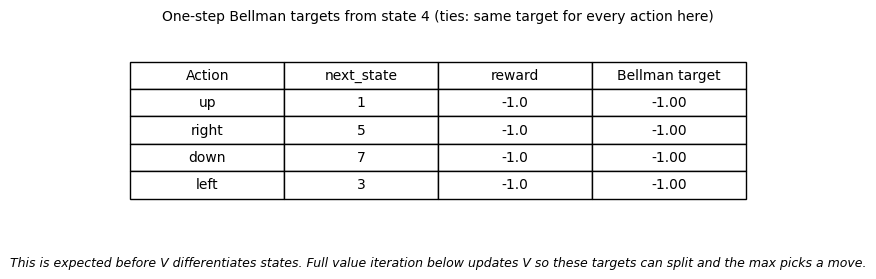


Best action value from state 4 (max over actions): -1.0
Full VI repeats this max idea for every state, every sweep.


In [2]:
# -----------------------------------------------------------------------------
# CELL: One-state Bellman warm-up (script, no def)
# Same r + gamma*V(s') computation you will see inside value_iteration, but for one state only.
# -----------------------------------------------------------------------------

# -----------------------------------------------------------------------------
# BLOCK: Initialize V=0 and pick a demo state
# V=0 makes each printed target equal immediate reward (until you run full VI).
# Names `warmup_values` / `warmup_action_returns` avoid clobbering `values` for the optional recap cell below.
# -----------------------------------------------------------------------------
# Create or choose a variable used in the Bellman warm-up demo.
# Save a value in a name so the next lines can read it.
warmup_values = np.zeros(N_STATES)
# Create or choose a variable used in the Bellman warm-up demo.
state = 4  # center of 3x3

# -----------------------------------------------------------------------------
# BLOCK: Loop all actions and print each one-step Bellman target
# transition() supplies (s', r); target is the candidate backup value for that fixed action.
# -----------------------------------------------------------------------------
# Show text or numbers in the cell output area under the code.
print(f"Inspecting state {state} before full value iteration:\n")

# Create a Python list that will store one scalar target per action.
# Save a value in a name so the next lines can read it.
warmup_action_returns = []
# Rows for a student-friendly table when every action ties (avoids four identical bars).
warmup_rows = []
# Start a loop: repeat the indented block once per item in the sequence.
for action, action_name in enumerate(ACTIONS):
    # Unpack the one-step model output from transition(state, action).
    next_state, reward = transition(state, action)
    # Compute one Bellman backup candidate: reward + gamma * V(next_state).
    target = reward + GAMMA * warmup_values[next_state]
    # Add one new item to the end of a list (the list grows in place).
    warmup_action_returns.append(target)
    # One table row: action label, next state id, reward, scalar target (strings for clean printing).
    warmup_rows.append([action_name, str(int(next_state)), f"{reward:.1f}", f"{target:.2f}"])
    # Show text or numbers in the cell output area under the code.
    print(
        # Build text with {…} holes filled in by variables (an f-string).
        f"Action {action_name:>5} -> next_state={next_state}, "
        # Build text with {…} holes filled in by variables (an f-string).
        f"reward={reward:>5}, target={target:>6.2f}"
    # Close the parentheses opened earlier (end this function call / grouping).
    )

# -----------------------------------------------------------------------------
# BLOCK: Visual — table when all actions tie; bar chart when they differ
# Identical bar heights make students think the plot is "broken". A table keeps the same numbers honest.
# -----------------------------------------------------------------------------
# Assign/update a variable used later in this cell or in other cells.
best_target = max(warmup_action_returns)
# True when every one-step target is the same (common with V=0 and a uniform step cost).
tied = min(warmup_action_returns) == best_target
# Branch: only run the next indented lines when this condition is true.
if tied:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6.4, 2.8))
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.axis("off")
    # Build a Matplotlib table so students see per-action next state and reward, not a fake "trend line".
    tbl = ax.table(
        cellText=warmup_rows,
        colLabels=["Action", "next_state", "reward", "Bellman target"],
        loc="center",
        cellLoc="center",
    )
    # Configure table font sizing for readability in the notebook.
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.15, 1.85)
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.set_title(
        f"One-step Bellman targets from state {state} (ties: same target for every action here)",
        fontsize=10,
        pad=10,
    )
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    fig.text(
        0.5,
        0.03,
        "This is expected before V differentiates states. Full value iteration below updates V so these targets can split and the max picks a move.",
        ha="center",
        fontsize=9,
        style="italic",
    )
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout(rect=(0, 0.12, 1, 1))
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()
# Else branch: runs when the matching if/elif chain was not taken.
else:
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.figure(figsize=(5, 3))
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.bar(ACTIONS, warmup_action_returns, color="steelblue")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.title(f"One-step action returns from state {state}")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.ylabel("Bellman target")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.axhline(best_target, linestyle="--", color="darkred", label="max over actions (= greedy backup)")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.legend()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()

# -----------------------------------------------------------------------------
# BLOCK: Read the max numerically (ties are normal early; VI later differentiates states)
# Connects the plot back to the Bellman optimality operator.
# -----------------------------------------------------------------------------
# Show text or numbers in the cell output area under the code.
print("\nBest action value from state 4 (max over actions):", best_target)
# Show text or numbers in the cell output area under the code.
print("Full VI repeats this max idea for every state, every sweep.")


## Part 2: Full Value Iteration

Now we run the full algorithm.

### Sweeps in the code below

In `value_iteration`, **one sweep** is one complete `while` iteration: the inner `for state in range(N_STATES)` visits each state, skips terminals, and applies the Bellman optimality update. After a sweep finishes, we append the largest single-state change to `deltas` and check whether the table has almost stopped moving (`delta < theta`). The convergence plot’s x-axis is the sweep index for that reason.

### What to watch for

- Do values near the goal become large and positive?
- Watch the pit's neighbors: they stay **positive** here. The Bellman **max** already assumes the best action, and the best action simply walks around the avoidable pit — so the danger shows up in the **policy arrows**, not as negative values. (Contrast the previous notebook, where *evaluating a weak fixed policy* that walks into the pit did produce strongly negative values.)
- Does the policy point around the pit instead of into it?

### Common misconception

Value iteration is **not** Q-learning.

- Value iteration assumes you know the transition model.
- Q-learning learns from interaction samples.

In Unit 1, value iteration is useful because it teaches planning clearly.

### Step Guide

**What this cell does:** Runs **value iteration** on the whole grid: it updates every state’s score table (`values`) sweep by sweep until it barely changes.

**How to read it (weak Python OK):** Watch two prints: the **list of `delta` per sweep** (should shrink) and the **final greedy `policy`** (arrows). The math inside the loops is the same Bellman idea as Part 1, just repeated for all states.

**What to expect in the output:** A short trace of convergence numbers, then arrays you can compare to the warm-up.

**If you feel lost:** Treat the `for` loops as “do the homework for every square on the board.” You do not need to trace every index on the first read—first notice *what gets smaller* (`delta`) and *what stabilizes* (`policy`).



State values:
  4.58   6.20   8.00
  6.20   8.00  10.00
  P     10.00   G   

Greedy policy:
 →   →   ↓ 
 →   →   ↓ 
 P   →   G 

Value iteration converged in 5 sweeps.
Final Bellman update size: 0.0

Summary:
- Value iteration applies the Bellman optimality update directly.
- It produces optimal state values for this small known MDP.
- A greedy policy can be extracted from those final values.
- In the next notebook, you move from planning in a known model to working with Gym environments.


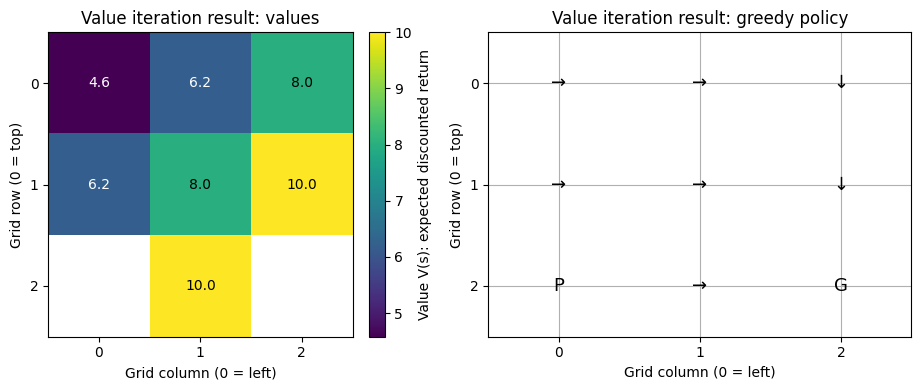

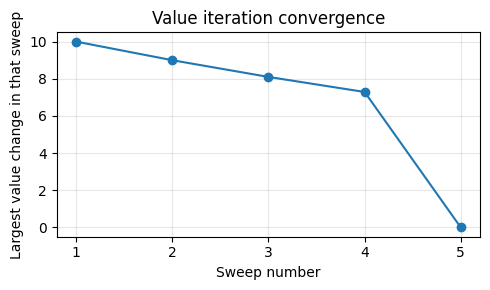

In [3]:
# -----------------------------------------------------------------------------
# CELL: Value iteration + greedy extraction + driver prints/plots
# Defines the planning functions, then runs them end-to-end.
# -----------------------------------------------------------------------------

# -----------------------------------------------------------------------------
# FUNCTION: value_iteration(gamma, theta)
# Synchronous sweeps: read old V, write new V for all states, repeat until updates are tiny.
# deltas records the largest |change| per sweep (used by plot_deltas).
# -----------------------------------------------------------------------------
# Function `value_iteration` (what it does): Run synchronous value iteration until max delta < theta; return (V, deltas).
def value_iteration(gamma=GAMMA, theta=1e-6):
    """Run synchronous value iteration until max delta < theta; return (V, deltas, tables).

    `tables` keeps a copy of the whole value table after every sweep (plus the all-zero
    table it started from), so a later cell can plot how the numbers actually settled.
    """
    # Create or choose a variable used in the Bellman warm-up demo.
    values = np.zeros(N_STATES)
    # Append or initialize the per-sweep convergence trace list.
    deltas = []
    # Sweep 0 is the table before any update: all zeros.
    tables = [values.copy()]

    # Start a loop: repeat the indented block while the condition stays True.
    while True:
        # Track how much the value table moved during the current sweep (or max change).
        delta = 0.0
        # Hold the updated V table for this sweep before swapping it into values.
        new_values = values.copy()
        # Start a loop: repeat the indented block once per item in the sequence.
        for state in range(N_STATES):
            # If the condition is True, run the indented block under this line.
            if state in TERMINAL_STATES:
                # Skip to the next lap of the loop (ignore the rest of this lap).
                continue
            # Create a Python list that will store one scalar target per action.
            action_returns = []
            # Start a loop: repeat the indented block once per item in the sequence.
            for action in range(len(ACTIONS)):
                # Unpack the one-step model output from transition(state, action).
                next_state, reward = transition(state, action)
                # Add one new item to the end of a list (the list grows in place).
                action_returns.append(reward + gamma * values[next_state])
            # Take the Bellman optimality max over the per-action backup list.
            best_value = max(action_returns)
            # Track how much the value table moved during the current sweep (or max change).
            delta = max(delta, abs(best_value - values[state]))
            # Hold the updated V table for this sweep before swapping it into values.
            new_values[state] = best_value
        # Create or choose a variable used in the Bellman warm-up demo.
        values = new_values
        # Add one new item to the end of a list (the list grows in place).
        deltas.append(delta)
        # Keep a snapshot of this sweep's table for the convergence figure below.
        tables.append(values.copy())
        # If the condition is True, run the indented block under this line.
        if delta < theta:
            # Stop the loop completely and continue after the loop block.
            break

    # Send a value back to whoever called this function.
    return values, deltas, tables

# -----------------------------------------------------------------------------
# FUNCTION: greedy_policy_from_values(values, gamma)
# Argmax of the same one-step returns: turns converged V into a deterministic greedy policy.
# -----------------------------------------------------------------------------
# Function `greedy_policy_from_values` (what it does): Extract a deterministic greedy policy by argmax over one-step Bellman targets.
def greedy_policy_from_values(values, gamma=GAMMA):
    """Extract a deterministic greedy policy by argmax over one-step Bellman targets."""
    # Create or update the greedy policy array (one int action id per state).
    policy = np.zeros(N_STATES, dtype=int)
    # Start a loop: repeat the indented block once per item in the sequence.
    for state in range(N_STATES):
        # If the condition is True, run the indented block under this line.
        if state in TERMINAL_STATES:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Create a Python list that will store one scalar target per action.
        action_returns = []
        # Start a loop: repeat the indented block once per item in the sequence.
        for action in range(len(ACTIONS)):
            # Unpack the one-step model output from transition(state, action).
            next_state, reward = transition(state, action)
            # Add one new item to the end of a list (the list grows in place).
            action_returns.append(reward + gamma * values[next_state])
        # Create or update the greedy policy array (one int action id per state).
        policy[state] = int(np.argmax(action_returns))
    # Send a value back to whoever called this function.
    return policy

# -----------------------------------------------------------------------------
# BLOCK: Run planning, print tables, print short summary, show figures
# Driver: no new math here—just calls the functions defined above and reuses plotting helpers.
# -----------------------------------------------------------------------------
# Store the planning outputs from running value_iteration / greedy extraction.
optimal_values, deltas, value_tables = value_iteration()
# Store the planning outputs from running value_iteration / greedy extraction.
optimal_policy = greedy_policy_from_values(optimal_values)

# Expose the converged table as `values` so the optional recap cell does not pick stale warm-up globals.
# Create or choose a variable used in the Bellman warm-up demo.
values = optimal_values

# Execute: print_values(optimal_values)
print_values(optimal_values)
# Execute: print_policy(optimal_policy)
print_policy(optimal_policy)
# Show text or numbers in the cell output area under the code.
print(f"\nValue iteration converged in {len(deltas)} sweeps.")
# Show text or numbers in the cell output area under the code.
print("Final Bellman update size:", deltas[-1])

# Show text or numbers in the cell output area under the code.
print("\nSummary:")
# Show text or numbers in the cell output area under the code.
print("- Value iteration applies the Bellman optimality update directly.")
# Show text or numbers in the cell output area under the code.
print("- It produces optimal state values for this small known MDP.")
# Show text or numbers in the cell output area under the code.
print("- A greedy policy can be extracted from those final values.")
# Show text or numbers in the cell output area under the code.
print("- In the next notebook, you move from planning in a known model to working with Gym environments.")

# Save a value in a name so the next lines can read it.
plot_values_and_policy(optimal_values, optimal_policy, title="Value iteration result")
# Execute: plot_deltas(deltas)
plot_deltas(deltas)


### Step Guide

**What this cell does:** Follows the value table sweep by sweep, so you can watch the numbers settle instead of only seeing the final answer.

**How to read it (weak Python OK):** The x axis is the sweep counter (0 is the all-zero table before any update). Each line is one tile of the grid. A line that has gone flat is a tile whose value has stopped changing.

**What to expect in the output:** One figure with seven lines and a printed sweep-by-sweep table underneath it.

**If you feel lost:** Follow one line only — `state 0 (row 0, col 0)`, the tile furthest from the goal. It is the last one to settle.

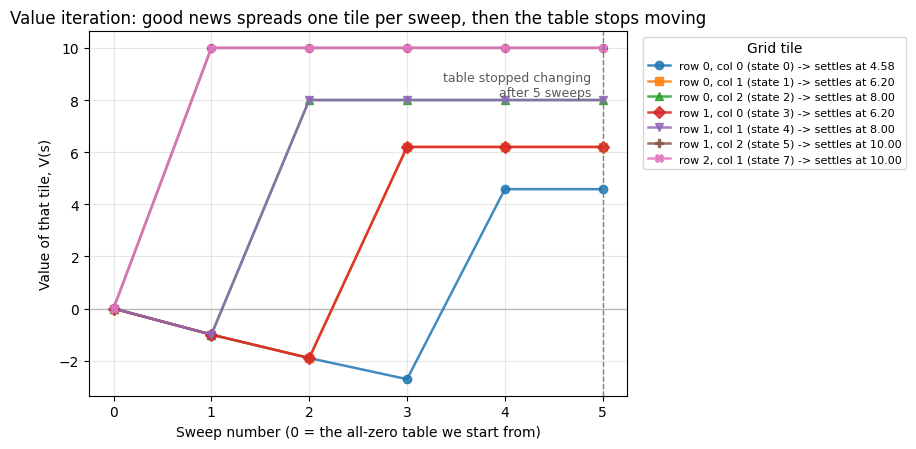

value of each tile after each sweep
sweep |   s0  |   s1  |   s2  |   s3  |   s4  |   s5  |   s7 
  0   |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00
  1   |  -1.00 |  -1.00 |  -1.00 |  -1.00 |  -1.00 |  10.00 |  10.00
  2   |  -1.90 |  -1.90 |   8.00 |  -1.90 |   8.00 |  10.00 |  10.00
  3   |  -2.71 |   6.20 |   8.00 |   6.20 |   8.00 |  10.00 |  10.00
  4   |   4.58 |   6.20 |   8.00 |   6.20 |   8.00 |  10.00 |  10.00
  5   |   4.58 |   6.20 |   8.00 |   6.20 |   8.00 |  10.00 |  10.00


In [4]:
# The lesson's real claim, drawn once: the value table stops moving.
# Each line is ONE tile of the grid, followed across the sweeps of value iteration. Sweeps
# are ordered in time, so a line is the honest mark here (plotting the states against each
# other would connect tiles that are not even neighbours).

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# value_tables[k] is the whole table after sweep k; value_tables[0] is the all-zero start.
history = np.array(value_tables)
# The x axis: sweep 0 (before any update) up to the final sweep.
sweeps = np.arange(history.shape[0])
# Several tiles end on the same value, so give each line its own marker shape as well as its
# own colour — otherwise two lines lying on top of each other cannot be told apart.
marker_shapes = ["o", "s", "^", "D", "v", "P", "X"]

# One panel; seven lines, one per non-terminal tile.
fig, ax = plt.subplots(figsize=(9, 4.6))
# Count the lines drawn so far so each gets the next marker shape.
line_index = 0
# Start a loop: repeat the indented block once per item in the sequence.
for state in range(N_STATES):
    # The two terminal tiles are never updated, so there is nothing to follow.
    if state in TERMINAL_STATES:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Describe each tile by where it sits on the grid, not by its raw index alone,
    # and put the settled value straight into the label so no text collides on the figure.
    row, col = to_pos(state)
    # Draw this tile's value across the sweeps.
    ax.plot(sweeps, history[:, state], marker=marker_shapes[line_index % len(marker_shapes)],
            markersize=6, linewidth=1.8, alpha=0.85,
            label=f"row {row}, col {col} (state {state}) -> settles at {history[-1, state]:.2f}")
    # Move on to the next marker shape.
    line_index += 1

# Mark the sweep on which the table stopped changing.
ax.axvline(len(deltas), color="0.5", linestyle="--", linewidth=1)
# Explain that dashed line in words, at the top of the panel where no line runs.
ax.text(len(deltas) - 0.12, history.max() - 0.9, f"table stopped changing\nafter {len(deltas)} sweeps",
        ha="right", va="top", fontsize=9, color="0.35")
# Zero is a meaningful level here: below it, a tile's current estimate is still negative.
ax.axhline(0.0, color="0.75", linewidth=1, zorder=0)

# Axis names in words, and whole-number ticks because sweeps are counted, not measured.
ax.set_xlabel("Sweep number (0 = the all-zero table we start from)")
ax.set_ylabel("Value of that tile, V(s)")
ax.set_xticks(sweeps)
# A title that states the claim the figure is making.
ax.set_title("Value iteration: good news spreads one tile per sweep, then the table stops moving")
# Put the legend outside the data area so it covers nothing.
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8, title="Grid tile")
# Same plot panel as the line above—one more small plotting tweak.
ax.grid(True, alpha=0.3)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()

# Print the same history as a table, so the picture can be checked rather than trusted.
print("value of each tile after each sweep")
print("sweep | " + " | ".join(f"  s{state} " for state in range(N_STATES) if state not in TERMINAL_STATES))
# Start a loop: repeat the indented block once per item in the sequence.
for k, table in enumerate(value_tables):
    # One row per sweep.
    print(f"  {k}   | " + " | ".join(f"{table[state]:6.2f}"
                                     for state in range(N_STATES) if state not in TERMINAL_STATES))


### 👁️ Read the figure

**What you are looking at.** One line per non-terminal tile, followed across the sweeps of value iteration. Sweep 0 is the table before any update, so every line starts at 0. The legend gives each tile's grid position and the value it settles on; the dashed line marks the sweep after which nothing changed any more.

**What to see.** Read it sweep by sweep and you can watch information travel. On **sweep 1**, only the two tiles next to the goal (row 1 col 2, and row 2 col 1) jump to 10.00 — they are the only tiles that can reach G in one move. Every other line *drops to -1.00*, because with an all-zero table the best any of them can do is pay the -1 step cost. On **sweep 2** the tiles two moves out reach 8.00, while the far corner sinks further to -1.90; on **sweep 3** the three-move tiles reach 6.20 and the corner is at -2.71; only on **sweep 4** does the good news finally reach row 0 col 0, which jumps from -2.71 to 4.58. Sweep 5 changes nothing, which is why the run reports 5 sweeps.

**What it proves:** two things worth more than the final table. First, "converged" is something you can *see* — every line is flat, and the printed table underneath gives the same numbers to check by eye. Second, an early negative value is **not** a claim that a tile is bad; it is an estimate that has not yet heard about the goal. Values are estimates in progress, and value iteration is the process of letting the +10 at G propagate outwards, one tile of distance per sweep.

## 💬 Discuss

The run above converged in **5 sweeps** with a final Bellman update size of **0.0**, and the greedy
policy walks right-right-down. Before that, Part 1 showed something odd: from state 4, *all four*
actions had target −1.00. Argue these out.

1. On the first sweep every action from state 4 looked identical. Value iteration still ended up
   with a clear preference. Explain — in words, to someone who has not seen the code — where the
   information that broke the tie came from, and how many sweeps it had to travel to get there.
2. This grid used `gamma = 0.90`. ACAS X's discount decides how much a possible collision twenty
   seconds from now counts against a nuisance alert right now. If you were on the committee, would
   you argue for a higher or a lower discount, and what would the other side say? Whose complaint
   would reach the newspapers first?
3. We converged to `delta = 0.0` because this MDP is tiny and deterministic. In practice you stop at
   `delta < theta` for some small `theta`. Who decides `theta`, and what would you need to show a
   regulator to defend the value you picked?


## ⚠️ Where this breaks

**The assumption that has to hold:** you can enumerate every state, and you have the transition
probabilities. Value iteration touches all of them, every sweep.

- **The table explodes.** This is not a theoretical worry — it is the operational problem in the real
  case above. The dynamic-programming table for ACAS Xu (the unmanned-aircraft variant) came out at
  *hundreds of gigabytes* of floating-point storage, which no avionics box will carry. Julian et
  al.'s answer was to train a neural network to approximate the table, cutting storage by a factor
  of about **1000**. Notice the shape of that fix: it is the same move that takes you from Unit 2's
  Q-tables to Unit 3's deep Q-networks.
- **You must already know the dynamics.** Every line in the sweep below reads `P(s'|s,a)` and
  `R(s,a)`. If you have to *discover* them by acting, none of this runs — go to Unit 2.
- **Discretisation is a modelling decision, not a formality.** Aircraft positions are continuous;
  somebody chose the grid. Too coarse and the policy is wrong between grid points; too fine and you
  are back at hundreds of gigabytes. The 3×3 grid here hides that entire argument.
- **Cheaper alternative:** when the model is known, the state space is small *and* the problem is
  deterministic, a plain shortest-path search (Dijkstra, A*) answers the same question faster and
  with nothing to tune. Reach for value iteration when transitions are genuinely probabilistic — that
  is what a path-finder cannot represent, and it is why aviation used it.


## Closing Takeaway

**Teaching takeaway:** Value iteration works by repeatedly asking: what is the best possible return from this state if I act optimally now?

**If students remember one idea:** The Bellman optimality update is the engine of value iteration and the foundation of many later RL methods.

**Quick check before moving on:**
- Can you explain why value iteration uses a max over actions?
- Can you extract the policy idea from the learned state values?

**Bridge to the next step:** After learning how to solve small MDPs exactly, you are ready to work with interactive RL environments.

**For weaker coders:** If the loops still feel fuzzy, re-run Part 1 only and write on paper one row: *state → best action → reward + next state*. That single row is the same idea the loops automate in Part 2.


## Motion recap (optional)

**Heads-up (tooling preview):** this cell uses the **Gymnasium** toolkit (`gym.make`, `reset`/`step`), which is properly introduced in `04_openai_gym_setup.ipynb`. For now, just watch the motion — the API details come in lesson 04.

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.


In [5]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Bellman, R. (1957). *Dynamic Programming*. Princeton University Press.
2. Puterman, M. L. (1994). *Markov Decision Processes: Discrete Stochastic Dynamic Programming*. Wiley.
3. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 4, Dynamic Programming — value iteration.
4. Schrittwieser, J., Antonoglou, I., Hubert, T. et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model* (MuZero). Nature. <https://arxiv.org/abs/1911.08265>
5. Ávila Pires, B., Rowland, M., Borsa, D. et al. (2025). *Optimizing Return Distributions with Distributional Dynamic Programming*. arXiv:2501.13028. <https://arxiv.org/abs/2501.13028> — distributional value and policy iteration: the same sweeps, applied to the whole return distribution instead of its mean.
6. Snell, C., Lee, J., Xu, K. & Kumar, A. (2024). *Scaling LLM Test-Time Compute Optimally can be More Effective than Scaling Model Parameters*. arXiv:2408.03314. <https://arxiv.org/abs/2408.03314> — the same "how much computation can I afford before I must commit to an answer" trade-off, moved to inference time in language models.
"""))

## 📚 References

1. Bellman, R. (1957). *Dynamic Programming*. Princeton University Press.
2. Puterman, M. L. (1994). *Markov Decision Processes: Discrete Stochastic Dynamic Programming*. Wiley.
3. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 4, Dynamic Programming — value iteration.
4. Schrittwieser, J., Antonoglou, I., Hubert, T. et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model* (MuZero). Nature. <https://arxiv.org/abs/1911.08265>
5. Ávila Pires, B., Rowland, M., Borsa, D. et al. (2025). *Optimizing Return Distributions with Distributional Dynamic Programming*. arXiv:2501.13028. <https://arxiv.org/abs/2501.13028> — distributional value and policy iteration: the same sweeps, applied to the whole return distribution instead of its mean.
6. Snell, C., Lee, J., Xu, K. & Kumar, A. (2024). *Scaling LLM Test-Time Compute Optimally can be More Effective than Scaling Model Parameters*. arXiv:2408.03314. <https://arxiv.org/abs/2408.03314> — the same "how much computation can I afford before I must commit to an answer" trade-off, moved to inference time in language models.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=9 | term=True | trunc=False


objc[75001]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114aec138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114fe89c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[75001]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114aec188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114fe8a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[75001]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114aebc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114fe8a68). T

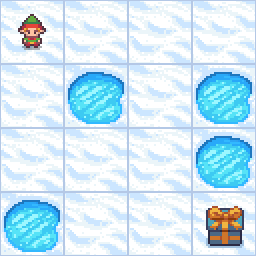

In [6]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install gymnasium pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
